<a href="https://colab.research.google.com/github/yashrajpisal/smart-cargo-inspection/blob/main/cargo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/sixray_v3"

In [ ]:
import os

img_dir = "/content/drive/MyDrive/sixray_v3/train/images"
label_dir = "/content/drive/MyDrive/sixray_v3/train/labels"

for img in os.listdir(img_dir):
    if img.endswith(".png"):
        label = img.replace(".png", ".txt")
        if not os.path.exists(os.path.join(label_dir, label)):
            print("❌ Missing label:", img)

print("✅ Train check done")

✅ Train check done


In [ ]:
%%writefile sixray_v3.yaml
path: /content/drive/MyDrive/sixray_v3

train: train/images
val: val/images
test: test/images

names:
  0: gun
  1: knife
  2: wrench
  # add your classes

Overwriting sixray_v3.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="sixray_v3.yaml",
    epochs=30,
    imgsz=416,
    batch=16,   # can increase in GPU
    device=0    # GPU
)

Ultralytics 8.4.27 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=sixray_v3.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

In [ ]:
!cp runs/detect/train2/weights/last.pt /content/drive/MyDrive/

In [ ]:
model = YOLO("/content/drive/MyDrive/best.pt")


image 1/1 /content/drive/MyDrive/sixray_v3/test/images/P00143_jpg.rf.09e8048547220b647acd21af431198c0.jpg: 320x416 2 knifes, 2 guns, 8.1ms
Speed: 1.8ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 416)


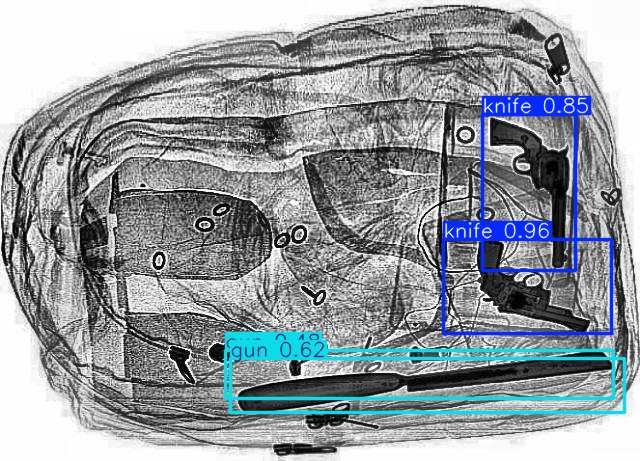

In [ ]:
results = model("/content/drive/MyDrive/sixray_v3/test/images/P00143_jpg.rf.09e8048547220b647acd21af431198c0.jpg", conf=0.4)
results[0].show()

In [ ]:
results = model("/content/drive/MyDrive/sixray_v3/test/images/P00031_jpg.rf.ddd74259050cdab35bd4ac8a153ff40f.jpg", save=True)


image 1/1 /content/drive/MyDrive/sixray_v3/test/images/P00031_jpg.rf.ddd74259050cdab35bd4ac8a153ff40f.jpg: 320x416 3 knifes, 1 gun, 8.2ms
Speed: 1.8ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


In [ ]:
git clone